In [1]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

#loading the dataset

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#data cleanup

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

In [3]:
df_US = df[df['job_country'] == 'United States'].copy()
df_US['job_posted_month']=df_US['job_posted_date'].dt.strftime('%B')
df_US_pivot = df_US.pivot_table(index= 'job_posted_month', columns= 'job_title_short', aggfunc= 'size')
df_US_pivot = df_US_pivot.reset_index()
df_US_pivot['job_posted_month_no'] = pd.to_datetime(df_US_pivot['job_posted_month'], format='%B').dt.month
df_US_pivot = df_US_pivot.sort_values('job_posted_month_no')
df_US_pivot = df_US_pivot.set_index('job_posted_month')
df_US_pivot = df_US_pivot.drop(columns='job_posted_month_no')

df_US_pivot

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_posted_month,,,,,,,,,,
January,527,36,8494,2655,6915,60,1544,773,1552,114
February,447,24,6124,3060,4956,56,1258,878,1127,90
March,438,19,6218,3183,4779,59,1114,829,1150,115
April,565,40,6049,2801,4867,51,1025,781,991,112
May,279,20,4993,2976,4377,49,839,746,914,90
June,446,32,5683,2893,4645,48,1009,812,1033,93
July,581,39,5201,2570,4876,65,883,747,1095,153
August,903,39,6634,3269,6318,68,1186,903,1515,194
September,897,50,4639,3224,4568,113,805,775,1014,228


In [8]:
df_US_software_pivot = pd.read_csv("https://lukeb.co/software_csv", index_col='job_posted_month')
df_US_software_pivot

,Front-End Developer,Back-End Developer,Full-Stack Developer,UI/UX Designer
job_posted_month,,,,
January,13619,9827,5108,4348
February,11456,9116,7298,4284
March,11102,8178,5814,4159
April,14037,9209,7232,4220
May,12126,8864,6718,4980
June,12003,8065,5902,4781
July,11914,8061,6839,4344
August,11571,8191,7413,4104
September,14016,8447,6139,4094


In [10]:
df_US_merged = df_US_pivot.merge(df_US_software_pivot, on="job_posted_month")
df_US_merged

,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer,Front-End Developer,Back-End Developer,Full-Stack Developer,UI/UX Designer
job_posted_month,,,,,,,,,,,,,,
January,527,36,8494,2655,6915,60,1544,773,1552,114,13619,9827,5108,4348
February,447,24,6124,3060,4956,56,1258,878,1127,90,11456,9116,7298,4284
March,438,19,6218,3183,4779,59,1114,829,1150,115,11102,8178,5814,4159
April,565,40,6049,2801,4867,51,1025,781,991,112,14037,9209,7232,4220
May,279,20,4993,2976,4377,49,839,746,914,90,12126,8864,6718,4980
June,446,32,5683,2893,4645,48,1009,812,1033,93,12003,8065,5902,4781
July,581,39,5201,2570,4876,65,883,747,1095,153,11914,8061,6839,4344
August,903,39,6634,3269,6318,68,1186,903,1515,194,11571,8191,7413,4104
September,897,50,4639,3224,4568,113,805,775,1014,228,14016,8447,6139,4094


In [15]:
top_5 = df_US_merged.sum().sort_values(ascending=False).head().index.to_list()
top_5

['Front-End Developer',
 'Back-End Developer',
 'Full-Stack Developer',
 'Data Analyst',
 'Data Scientist']

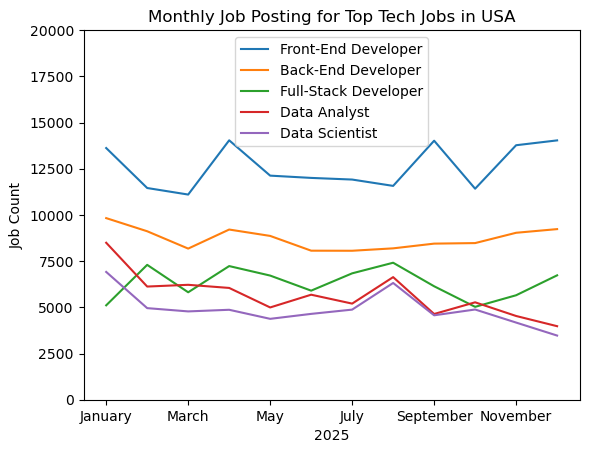

In [18]:
df_US_merged[top_5].plot(kind='line')
plt.title('Monthly Job Posting for Top Tech Jobs in USA')
plt.xlabel('2025')
plt.ylabel('Job Count')
plt.ylim(0, 20000)
plt.legend()
plt.show()

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        785741 non-null  str           
 1   job_title              785740 non-null  str           
 2   job_location           784696 non-null  str           
 3   job_via                785733 non-null  str           
 4   job_schedule_type      773074 non-null  str           
 5   job_work_from_home     785741 non-null  bool          
 6   search_location        785741 non-null  str           
 7   job_posted_date        785741 non-null  datetime64[us]
 8   job_no_degree_mention  785741 non-null  bool          
 9   job_health_insurance   785741 non-null  bool          
 10  job_country            785692 non-null  str           
 11  salary_rate            33067 non-null   str           
 12  salary_year_avg        22003 non-null   float64       


In [26]:
## Step 1: Create pivot for main roles
df_US_pivot = df_US.pivot_table(
    index='job_posted_month',
    columns='job_title_short',
    values='job_title',
    aggfunc='count'
)

# Step 2: Create pivot for software roles (example filter)
df_US_software = df_US[df_US['job_title_short'].str.contains('Developer', na=False)]

df_US_software_pivot = df_US_software.pivot_table(
    index='job_posted_month',
    columns='job_title_short',
    values='job_title',
    aggfunc='count'
)

# Step 3: Merge both pivot tables
df_US_merged = df_US_pivot.merge(
    df_US_software_pivot,
    on='job_posted_month',
    how='left'
)

# Step 4: Clean column names
df_US_merged.columns.name = None

# Step 5: Sort months properly
month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

df_US_merged = df_US_merged.reindex(month_order)

# Final output
df_US_merged

,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_posted_month,,,,,,,,,,
January,527,36,8494,2655,6915,60,1544,773,1552,114
February,447,24,6124,3060,4956,56,1258,878,1127,90
March,438,19,6218,3183,4779,59,1114,829,1150,115
April,565,40,6049,2801,4867,51,1025,781,991,112
May,279,20,4993,2976,4377,49,839,746,914,90
June,446,32,5683,2893,4645,48,1009,812,1033,93
July,581,39,5201,2570,4876,65,883,747,1095,153
August,903,39,6634,3269,6318,68,1186,903,1515,194
September,897,50,4639,3224,4568,113,805,775,1014,228


,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_posted_month,job_count
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,NaN,NaN,June,16694
1,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"['python', 'c++', 'java', 'matlab', 'aws', 'te...","{'cloud': ['aws'], 'libraries': ['tensorflow',...",July,16210
2,Data Engineer,GCP Data Engineer,Anywhere,via ZipRecruiter,Contractor and Temp work,True,Georgia,2023-11-07 14:01:59,False,False,United States,NaN,NaN,NaN,smart folks inc,"['python', 'sql', 'gcp']","{'cloud': ['gcp'], 'programming': ['python', '...",November,14736
3,Senior Data Engineer,Senior Data Engineer - GCP Cloud,"Dearborn, MI",via LinkedIn,Full-time,False,"Florida, United States",2023-03-27 13:18:18,False,False,United States,NaN,NaN,NaN,"Miracle Software Systems, Inc","['sql', 'python', 'java', 'sql server', 'gcp',...","{'cloud': ['gcp', 'bigquery'], 'databases': ['...",March,17904
4,Data Scientist,Data Scientist II,Anywhere,via ZipRecruiter,Full-time,True,"New York, United States",2023-04-23 13:02:57,False,False,United States,NaN,NaN,NaN,"Radwell International, LLC","['sql', 'python', 'r', 'mongodb', 'mongodb', '...","{'analyst_tools': ['excel'], 'cloud': ['azure'...",April,17282


In [ ]:
# Step 1: Filter US jobs
df_US = df[df['job_country'] == 'United States'].copy()

# Step 2: Create month column
df_US['job_posted_month'] = df_US['job_posted_date'].dt.strftime('%B')

# Step 3: Pivot → job counts per month
df_US_pivot = df_US.pivot_table(
    index='job_posted_month',
    columns='job_title_short',
    aggfunc='size'
)

# Step 4: Reset index for sorting
df_US_pivot = df_US_pivot.reset_index()

# Step 5: Sort months properly
df_US_pivot['job_posted_month_no'] = pd.to_datetime(
    df_US_pivot['job_posted_month'],
    format='%B'
).dt.month

df_US_pivot = df_US_pivot.sort_values('job_posted_month_no')

# Step 6: Set index back
df_US_pivot = df_US_pivot.set_index('job_posted_month')

# Step 7: Drop helper column
df_US_pivot = df_US_pivot.drop(columns='job_posted_month_no')


# ---------------- NEW PART ---------------- #

# Step 8: Non-remote jobs count per month
df_non_remote = df_US[df_US['job_work_from_home'] == False]

df_non_remote_count = df_non_remote.groupby('job_posted_month').size().rename('Non_Remote_Jobs')


# Step 9: Median salary per month
df_salary = df_US.groupby('job_posted_month')['salary_year_avg'].median().rename('Median_Salary')


# Step 10: Merge everything
df_US_final = df_US_pivot.merge(
    df_non_remote_count,
    left_index=True,
    right_index=True,
    how='left'
)

df_US_final = df_US_final.merge(
    df_salary,
    left_index=True,
    right_index=True,
    how='left'
)

# Final output
df_US_final

,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer,Non_Remote_Jobs,Median_Salary
job_posted_month,,,,,,,,,,,,
January,527,36,8494,2655,6915,60,1544,773,1552,114,20272,120000.0
February,447,24,6124,3060,4956,56,1258,878,1127,90,16225,120000.0
March,438,19,6218,3183,4779,59,1114,829,1150,115,15931,122500.0
April,565,40,6049,2801,4867,51,1025,781,991,112,15539,117800.0
May,279,20,4993,2976,4377,49,839,746,914,90,13560,122500.0
June,446,32,5683,2893,4645,48,1009,812,1033,93,14836,120000.0
July,581,39,5201,2570,4876,65,883,747,1095,153,14481,122500.0
August,903,39,6634,3269,6318,68,1186,903,1515,194,19470,117500.0
September,897,50,4639,3224,4568,113,805,775,1014,228,14282,119000.0
